<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked    

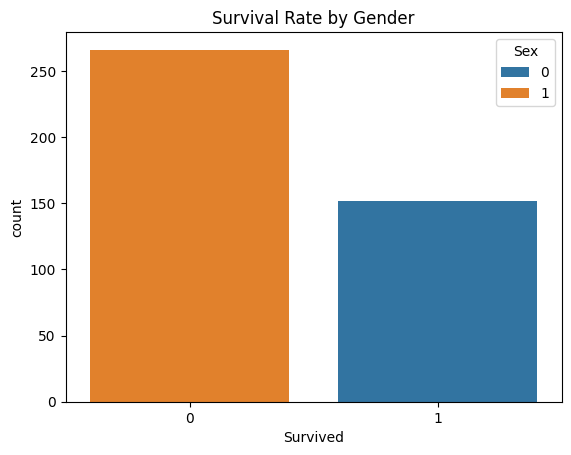

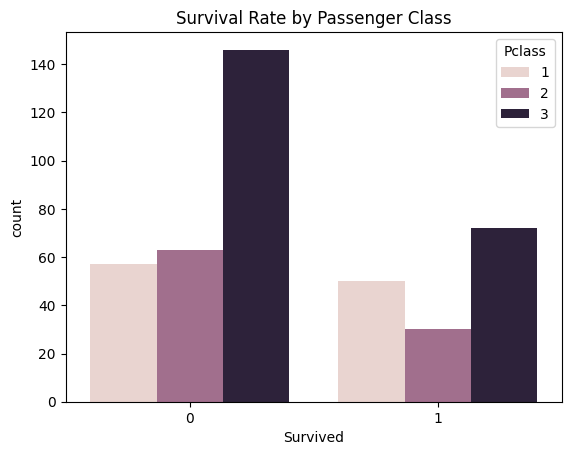

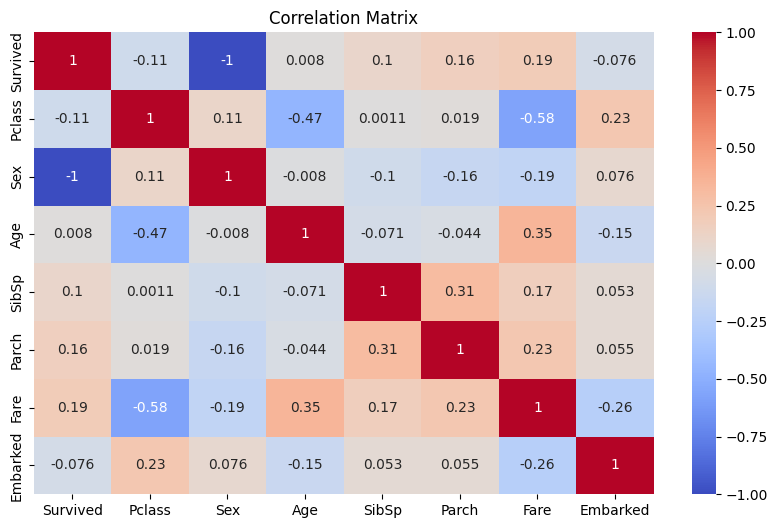

Accuracy Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



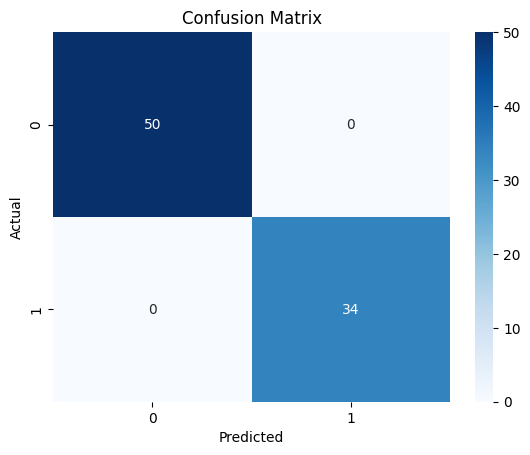

In [3]:
# Titanic Survival Prediction - NeuroNexus Task
# Author: Sheikh Fayiz
# Dataset: tested.csv (uploaded)

# ----------------------------
# 1. Import Required Libraries
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# 2. Load the Dataset
# ----------------------------
df = pd.read_csv("tested.csv")
df.head()
# ----------------------------
# 3. Initial Data Inspection
# ----------------------------
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
# ----------------------------
# 4. Data Cleaning
# ----------------------------

# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=Trueue)

# Fill missing Embarked with most frequent
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=Trueue)

# Drop Cabin (too many missing values)
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1), inplace=Trueue)

# Encode categorical features
label_enc = LabelEncoder()
df['Sex'] = label_enc.fit_transform(df['Sex'])
df['Embarked'] = label_enc.fit_transform(df['Embarked'])

df.head()
# ----------------------------
# 5. Exploratory Data Analysis
# ----------------------------

# Survival rate by gender
sns.countplot(data=df, x='Survived', hue='Sex')
plt.title('Survival Rate by Gender')
plt.show()

# Survival rate by class
sns.countplot(data=df, x='Survived', hue='Pclass')
plt.title('Survival Rate by Passenger Class')
plt.show()

# Heatmap of correlations
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
# ----------------------------
# 6. Train/Test Split
# ----------------------------
X = df.drop('Survived', axis=1))
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# ----------------------------
# 7. Model Training
# ----------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# ----------------------------
# 8. Model Evaluation
# ----------------------------
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [2]:
from google.colab import files
uploaded = files.upload()


Saving tested.csv to tested.csv
